<a href="https://colab.research.google.com/github/ManoloArriola/black-swan-analysis/blob/main/The_Black_Swan_in_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Black Swan in Consumption**



# Black Swan Detection: From Global Markets to Regional Context
## Project Overview
This project explores **Nassim Taleb's Black Swan Theory** through data analysis. While I initially analyze global giants like **Toyota** and **Tesla**, the core objective is to build a robust framework that can be applied to any market, including emerging economies like **Guatemala**.

By identifying outliers (anomalies) in financial data, we can distinguish between predictable market behavior and extreme events that require urgent management decisions.

In [2]:
# Install the financial data library
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Download data
ticker = "TM"
data_real = yf.download(ticker, period="1y", interval="1d")

# 2. FIX: Flatten the data (Aplanar los títulos de las columnas)
# Esto elimina las capas extra que causan el ValueError
df_toyota = data_real[['Close']].copy()
df_toyota.columns = ['Close']
df_toyota = df_toyota.reset_index()

# 3. Calculate statistics safely
# Usamos .values[0] si el resultado es una serie, para obtener solo el número
mean_toyota = df_toyota['Close'].mean()
std_toyota = df_toyota['Close'].std()

upper_tm = mean_toyota + (3 * std_toyota)
lower_tm = mean_toyota - (3 * std_toyota)

# 4. Filter Black Swans
black_swans_tm = df_toyota[(df_toyota['Close'] > upper_tm) | (df_toyota['Close'] < lower_tm)]

print(f"Mean Price for {ticker}: {mean_toyota:.2f}")

/tmp/ipython-input-152/3429156545.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_real = yf.download(ticker, period="1y", interval="1d")
[*********************100%***********************]  1 of 1 completed

Mean Price for TM: 196.57


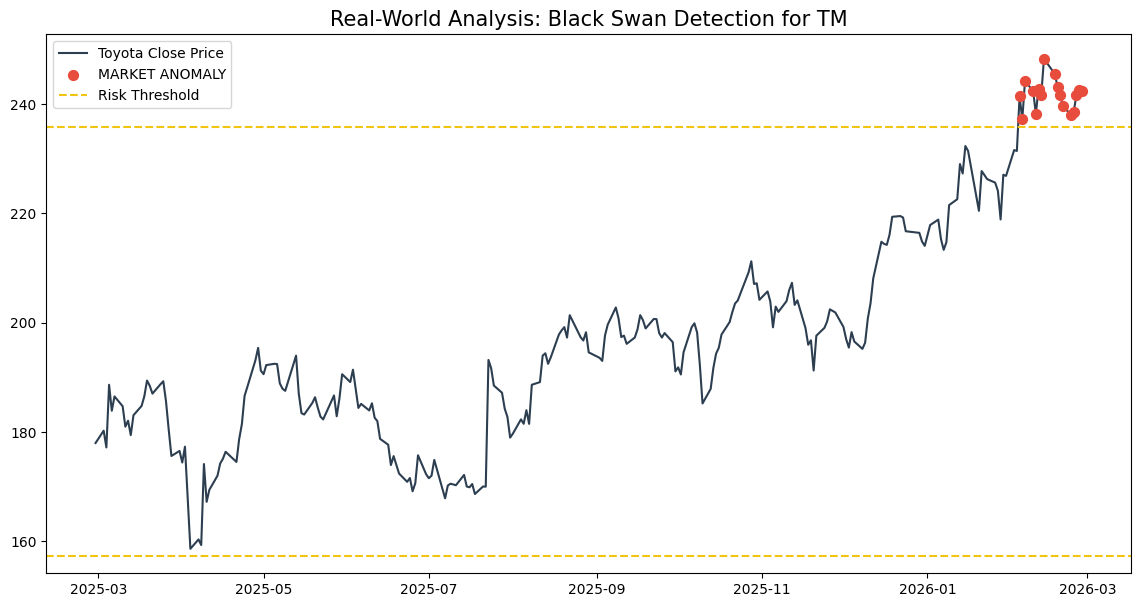

In [4]:
# 1. Calculate statistics
mean_toyota = df_toyota['Close'].mean()
std_toyota = df_toyota['Close'].std()

# 2. Define the 3-Sigma Thresholds
upper_tm = mean_toyota + (2 * std_toyota)
lower_tm = mean_toyota - (2 * std_toyota)

# 3. Identify Real Black Swans
black_swans_tm = df_toyota[(df_toyota['Close'] > upper_tm) | (df_toyota['Close'] < lower_tm)]

# 4. Visualization
plt.figure(figsize=(14, 7))
plt.plot(df_toyota['Date'], df_toyota['Close'], color='#2c3e50', label='Toyota Close Price')

# Highlight detected anomalies
plt.scatter(black_swans_tm['Date'], black_swans_tm['Close'], color='#e74c3c', s=50, label='MARKET ANOMALY', zorder=5)

# Threshold lines
plt.axhline(y=upper_tm, color='#f1c40f', linestyle='--', label='Risk Threshold')
plt.axhline(y=lower_tm, color='#f1c40f', linestyle='--')

plt.title(f'Real-World Analysis: Black Swan Detection for {ticker}', fontsize=15)
plt.legend()
plt.savefig('black_swan_analysis_toyota.png', dpi=300)
plt.show()

Let's add a comparision with another compani, Tesla in this case.


/tmp/ipython-input-152/4214291772.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_comp = yf.download(tickers, period="1y")['Close']
[*********************100%***********************]  2 of 2 completed


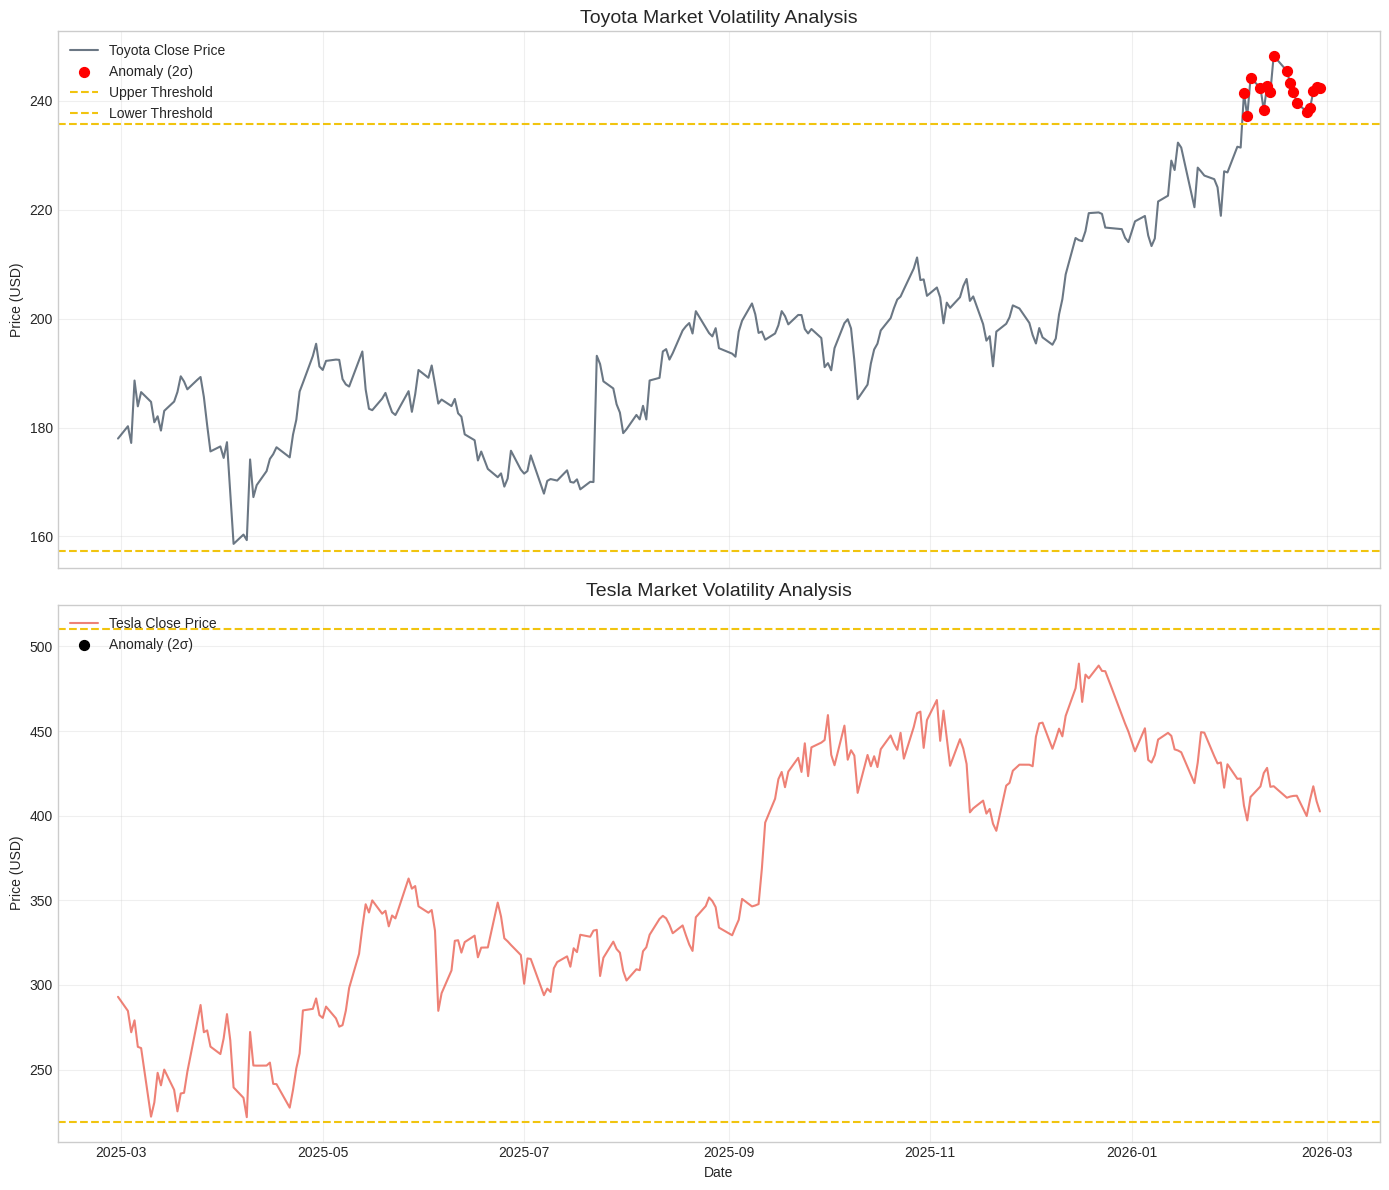

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Toyota Anomalies (2σ): 17
Tesla Anomalies (2σ): 0


In [7]:
# STEP 5 (REVISED): Comparative Analysis with Threshold Lines
tickers = ["TM", "TSLA"]
data_comp = yf.download(tickers, period="1y")['Close']
data_comp = data_comp.dropna()

def get_stats_and_swans(series):
    m = series.mean()
    s = series.std()
    upper = m + (2 * s) # High Sensitivity Threshold
    lower = m - (2 * s)
    swans = series[(series > upper) | (series < lower)]
    return m, upper, lower, swans

# Visualization Setup
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# --- Plot Toyota (TM) ---
# 1. Get stats
tm_mean, tm_upper, tm_lower, tm_swans = get_stats_and_swans(data_comp['TM'])

# 2. Draw Plot
ax1.plot(data_comp.index, data_comp['TM'], color='#2c3e50', label='Toyota Close Price', alpha=0.7)
ax1.scatter(tm_swans.index, tm_swans, color='red', s=50, label='Anomaly (2σ)', zorder=5)

# 3. Add Threshold Lines (The yellow lines you missed!)
ax1.axhline(y=tm_upper, color='#f1c40f', linestyle='--', label='Upper Threshold')
ax1.axhline(y=tm_lower, color='#f1c40f', linestyle='--', label='Lower Threshold')

ax1.set_title('Toyota Market Volatility Analysis', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)


# --- Plot Tesla (TSLA) ---
# 1. Get stats
tsla_mean, tsla_upper, tsla_lower, tsla_swans = get_stats_and_swans(data_comp['TSLA'])

# 2. Draw Plot
ax2.plot(data_comp.index, data_comp['TSLA'], color='#e74c3c', label='Tesla Close Price', alpha=0.7)
ax2.scatter(tsla_swans.index, tsla_swans, color='black', s=50, label='Anomaly (2σ)', zorder=5)

# 3. Add Threshold Lines
ax2.axhline(y=tsla_upper, color='#f1c40f', linestyle='--')
ax2.axhline(y=tsla_lower, color='#f1c40f', linestyle='--')

ax2.set_title('Tesla Market Volatility Analysis', fontsize=14)
ax2.set_ylabel('Price (USD)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()

# Save and Download with correct order
plt.savefig('market_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('market_comparison_final.png')

print(f"Toyota Anomalies (2σ): {len(tm_swans)}")
print(f"Tesla Anomalies (2σ): {len(tsla_swans)}")
